DAY 7

(OOP,NUMPY & PANDAS)

1) Create  a bankAccount class with deposit,withdraw, balance methods.

In [63]:
class BankAccount:
    def __init__(self, owner, initial_balance=0):
        self.owner = owner
        self._balance = initial_balance

    def deposit(self, amount):
        if amount <= 0:
            print("Deposit amount must be positive.")
            return
        self._balance += amount
        print(f"Deposited {amount}. New balance: {self._balance}")

    def withdraw(self, amount):
        if amount <= 0:
            print("Withdrawal amount must be positive.")
            return
        if amount > self._balance:
            print("Insufficient balance.")
            return
        self._balance -= amount
        print(f"Withdrew {amount}. New balance: {self._balance}")

    def balance(self):
        return self._balance
        


In [64]:
account = BankAccount("CHETNA", 1000)

account.deposit(500)
account.withdraw(200)

print("Current balance:", account.balance())

Deposited 500. New balance: 1500
Withdrew 200. New balance: 1300
Current balance: 1300


2) CREATE A NUMPY ARRAY : PERFORM SLICING, RESHAPPING, AND SATS(MEAN/STD/MAX).

In [65]:
import numpy as np
arr = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

print("Original Array:")
print(arr)

print("\nSlicing Operations:")
print("First 5 elements:", arr[:5])
print("Last 4 elements:", arr[-4:])
print("Elements from index 2 to 8:", arr[2:9])
print("Every 3rd element:", arr[::3])

reshaped_arr = arr.reshape(3, 4)  

print("\nReshaped Array (3x4):")
print(reshaped_arr)

print("\nStatistics:")
print("Mean:", np.mean(arr))
print("Standard Deviation:", np.std(arr))
print("Max Value:", np.max(arr))

Original Array:
[ 1  2  3  4  5  6  7  8  9 10 11 12]

Slicing Operations:
First 5 elements: [1 2 3 4 5]
Last 4 elements: [ 9 10 11 12]
Elements from index 2 to 8: [3 4 5 6 7 8 9]
Every 3rd element: [ 1  4  7 10]

Reshaped Array (3x4):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Statistics:
Mean: 6.5
Standard Deviation: 3.452052529534663
Max Value: 12


3) Load a CVS into pandas; display info(), describe(), handle(),handle missing values.


In [66]:
import pandas as pd

data = {
    "Name": ["chetna", "Sara", "bharti"],
    "Age": [22, 25, 23],
    "City": ["Delhi", "Mumbai", "London"]
}

df = pd.DataFrame(data)

df.to_csv("students.csv", index=False)
import pandas as pd

df = pd.read_csv("students.csv")
df.info()
df.isnull().sum()
df_clean = df.dropna()
df_clean = df.dropna(axis=1)


df.info()
df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    3 non-null      str  
 1   Age     3 non-null      int64
 2   City    3 non-null      str  
dtypes: int64(1), str(2)
memory usage: 204.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    3 non-null      str  
 1   Age     3 non-null      int64
 2   City    3 non-null      str  
dtypes: int64(1), str(2)
memory usage: 204.0 bytes


Name    0
Age     0
City    0
dtype: int64

4) Mini EDA: filter,  group by and ploy a bar chart.

In [67]:
import csv

data = [
    ["Name", "Age", "City"],
    ["chetna", 22, "Delhi"],
    ["Sara", 25, "Mumbai"],
    ["bharti", 30, "London"]
]

with open("students.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(data)
    import pandas as pd

df = pd.read_csv("students.csv")
df.head()
df_filtered = df[df["Age"] > 25]
print(df_filtered)
df_filtered = df[(df["Age"] > 25) & (df["City"] == "Delhi")]
print(df_filtered)
df_filtered = df[df["City"].isin(["Delhi", "Mumbai", "London"])]
print(df_filtered)

     Name  Age    City
2  bharti   30  London
Empty DataFrame
Columns: [Name, Age, City]
Index: []
     Name  Age    City
0  chetna   22   Delhi
1    Sara   25  Mumbai
2  bharti   30  London


In [68]:
import csv

data = [
    ["Name", "Age", "City"],
    ["chetna", 22, "Delhi"],
    ["Sara", 25, "Mumbai"],
    ["bharti", 30, "London"]
]

with open("students.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(data)
    import pandas as pd

df = pd.read_csv("students.csv")
df.head()
df_filtered = df[df["Age"] > 25]
print(df_filtered)

city_counts = df.groupby("City")["Name"].count()
print(city_counts)

     Name  Age    City
2  bharti   30  London
City
Delhi     1
London    1
Mumbai    1
Name: Name, dtype: int64


PRACTICE SHEET


1) OOP:Library sytem with Book and Member classes.

In [69]:
class Book:
    def __init__(self, title, author):
        self.title = title
        self.author = author
        self.is_issued = False

    def issue_book(self):
        if not self.is_issued:
            self.is_issued = True
            print(f"Book issued: {self.title}")
        else:
            print(f"Book already issued: {self.title}")

    def return_book(self):
        if self.is_issued:
            self.is_issued = False
            print(f"Book returned: {self.title}")
        else:
            print(f"Book was not issued: {self.title}")


class Member:
    def __init__(self, name):
        self.name = name
        self.borrowed_books = []

    def borrow_book(self, book):
        if not book.is_issued:
            book.issue_book()
            self.borrowed_books.append(book.title)
        else:
            print(f"{book.title} is not available")

    def return_book(self, book):
        if book.title in self.borrowed_books:
            book.return_book()
            self.borrowed_books.remove(book.title)
        else:
            print(f"{self.name} did not borrow {book.title}")

    def show_books(self):
        print(f"{self.name}'s borrowed books: {self.borrowed_books}")
        book1 = Book("Python Basics", "John Doe")
book2 = Book("Data Science", "Jane Smith")


In [70]:
book1 = Book("Python Basics", "John Doe")
book2 = Book("Data Science", "Jane Smith")

# Create member
member1 = Member("Amit")

# Borrow books
member1.borrow_book(book1)
member1.borrow_book(book2)

# Show borrowed books
member1.show_books()

# Return a book
member1.return_book(book1)

# Show again
member1.show_books()

Book issued: Python Basics
Book issued: Data Science
Amit's borrowed books: ['Python Basics', 'Data Science']
Book returned: Python Basics
Amit's borrowed books: ['Data Science']


2) Numpy: matrix multiplication without loops.

In [71]:
import numpy as np
A = np.array([[4,2],
              [3, 4]])

B = np.array([[7,6],
              [7, 8]])
C = A @ B
print(C)

[[42 40]
 [49 50]]


In [72]:
import numpy as np
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])
C = np.dot(A, B)
print(C)

[[19 22]
 [43 50]]


3) Pndas analyse titanic or iris dataset(kaggle)

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    4 non-null      str  
 1   Age     4 non-null      int64
 2   City    4 non-null      str  
dtypes: int64(1), str(2)
memory usage: 228.0 bytes


C:\Users\user1\AppData\Local\Temp\ipykernel_16800\3376876890.py:20: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"].fillna(df["Age"].median(), inplace=True)


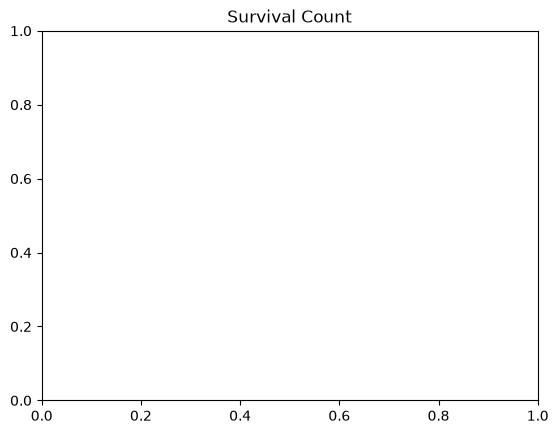

In [73]:
import pandas as pd

data = {
    "Name": ["Amit", "Sara", "John", "Ravi"],
    "Age": [22, 25, 30, 28],
    "City": ["Delhi", "Mumbai", "London", "Chennai"]
}

df = pd.DataFrame(data)

df.to_csv("students.csv", index=False)
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("students.csv")
df.head()
df.info()
df.describe()
df.isnull().sum()
df["Age"].fillna(df["Age"].median(), inplace=True)
import matplotlib.pyplot as plt

plt.title("Survival Count")
plt.show()

Iris dataset (kaggle)